In [ ]:
!pip install requests

In [ ]:
# Install necessary libraries
!pip install pandas numpy scikit-learn tensorflow matplotlib plotly skyfield

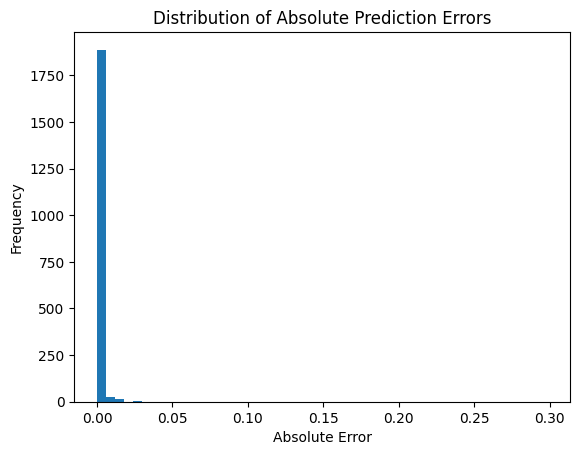

In [12]:
import matplotlib.pyplot as plt

# Create a histogram of the 'Absolute_Error' column
plt.hist(comparison_df['Absolute_Error'], bins=50)

# Add a title and labels to the histogram
plt.title('Distribution of Absolute Prediction Errors')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')

# Display the histogram
plt.show()

In [11]:
import pandas as pd
import numpy as np

# Use the trained model to predict the 'APOGEE_ALTITUDE' for the X_test dataset.
y_pred = model.predict(X_test)

# Create a pandas DataFrame to compare the actual y_test values and the predicted y_pred values.
comparison_df = pd.DataFrame({'Actual_APOGEE_ALTITUDE': y_test, 'Predicted_APOGEE_ALTITUDE': y_pred})

# Include a column in comparison_df that shows the absolute difference between the actual and predicted values.
comparison_df['Absolute_Error'] = np.abs(comparison_df['Actual_APOGEE_ALTITUDE'] - comparison_df['Predicted_APOGEE_ALTITUDE'])

# Display the first few rows of comparison_df to visually inspect the predictions and errors.
display(comparison_df.head())

# Calculate and print the mean and standard deviation of the 'Absolute_Error'.
mean_absolute_error_value = comparison_df['Absolute_Error'].mean()
std_absolute_error_value = comparison_df['Absolute_Error'].std()

print(f'Mean Absolute Error: {mean_absolute_error_value}')
print(f'Standard Deviation of Absolute Error: {std_absolute_error_value}')

,Actual_APOGEE_ALTITUDE,Predicted_APOGEE_ALTITUDE,Absolute_Error
4022,-0.363810,-0.363800,0.000010
1103,-0.329145,-0.329152,0.000007
8035,-0.359473,-0.359469,0.000004
5193,-0.373154,-0.373141,0.000014
5884,-0.295612,-0.295622,0.000010


Mean Absolute Error: 0.0006563423663581799
Standard Deviation of Absolute Error: 0.0073482946057725936


In [10]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Calculate R-squared score
r_squared = model.score(X_test, y_test)
print(f'R-squared: {r_squared}')

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

R-squared: 0.9999439265067999
Mean Absolute Error: 0.0006563423663581778
Root Mean Squared Error: 0.007375655824106455


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Define features (X) and target (y)
X = scaled_df.drop(columns=['APOGEE_ALTITUDE', 'PERIGEE_ALTITUDE'])
y = scaled_df['APOGEE_ALTITUDE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 5.440029883567547e-05


In [8]:
from sklearn.preprocessing import StandardScaler

# Select numerical features, excluding 'NORAD_CAT_ID' and 'EPOCH_UNIX'
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['NORAD_CAT_ID', 'EPOCH_UNIX'])

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the numerical features
scaled_features = scaler.fit_transform(numerical_features)

# Create a new DataFrame with scaled features
scaled_df = pd.DataFrame(scaled_features, columns=numerical_features.columns)

# Display the first few rows of the scaled DataFrame
display(scaled_df.head())

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
0,-0.171209,-0.329039,-1.421548,0.953752,1.672787,-1.598954,-0.254722,0.026583,-0.063427,-0.216840,-0.191086,0.141616,0.026583,-0.254722
1,0.341643,-0.333990,-0.626311,-0.995439,0.443012,-0.439763,-0.331819,-0.146460,-0.082189,-0.291809,-0.309860,0.358510,-0.146460,-0.331819
2,0.440277,-0.349141,-0.634494,1.528191,1.604306,-1.534001,-0.346641,-0.171120,-0.077669,-0.304050,-0.329798,0.409742,-0.171120,-0.346641
3,0.362033,-0.344685,-0.621003,1.516021,1.091624,-1.054254,-0.335944,-0.149281,-0.081941,-0.294390,-0.314049,0.375282,-0.149281,-0.335944
4,0.464210,-0.359849,-0.627919,0.105834,-0.490689,0.456339,-0.351075,-0.174788,-0.065267,-0.306931,-0.334514,0.427892,-0.174788,-0.351075


In [7]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/space_debris_with_engineered_features.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

# Display the column names and their data types
display(df.info())

# Display a concise summary of the DataFrame
display(df.describe())

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
0,51,1754742671,12.183623,0.010673,47.2135,293.7644,348.9420,10.9027,1684.833,1514.536,0.000467,7091.486668,7977.819514,6.999706,-4856.464,-4686.167
1,121,1754712212,14.001546,0.009819,66.7470,97.0978,226.1690,133.1247,964.658,821.866,0.000061,6170.747215,7271.396893,7.338745,-5549.134,-5406.342
2,124,1754736595,14.351177,0.007203,66.5460,351.7232,342.1053,17.7511,826.202,723.152,0.000159,6020.412027,7152.812203,7.418827,-5647.848,-5544.798
3,125,1754703788,14.073826,0.007973,66.8774,350.4953,290.9223,68.3344,926.118,810.571,0.000066,6139.055699,7246.479404,7.364961,-5560.429,-5444.882
4,126,1754731663,14.436013,0.005355,66.7075,208.2124,132.9542,227.6073,784.781,708.472,0.000427,5985.032062,7124.761547,7.447198,-5662.528,-5586.219


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9669 entries, 0 to 9668
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NORAD_CAT_ID       9669 non-null   int64  
 1   EPOCH_UNIX         9669 non-null   int64  
 2   MEAN_MOTION        9669 non-null   float64
 3   ECCENTRICITY       9669 non-null   float64
 4   INCLINATION        9669 non-null   float64
 5   RA_OF_ASC_NODE     9669 non-null   float64
 6   ARG_OF_PERICENTER  9669 non-null   float64
 7   MEAN_ANOMALY       9669 non-null   float64
 8   APOAPSIS           9669 non-null   float64
 9   PERIAPSIS          9669 non-null   float64
 10  BSTAR              9669 non-null   float64
 11  ORBITAL_PERIOD     9669 non-null   float64
 12  SEMI_MAJOR_AXIS    9669 non-null   float64
 13  ORBITAL_VELOCITY   9669 non-null   float64
 14  PERIGEE_ALTITUDE   9669 non-null   float64
 15  APOGEE_ALTITUDE    9669 non-null   float64
dtypes: float64(14), int64(2)

None

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
count,9669.000000,9.669000e+03,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000
mean,34976.668735,1.754600e+09,12.790513,0.067468,82.131174,197.534110,181.941474,179.492125,4064.258502,1408.125930,0.001841,9754.619726,9114.327215,6.778337,-4962.874070,-2306.741498
std,14355.806933,2.490663e+05,3.544919,0.172616,24.564409,100.901721,99.838860,105.442787,9341.734536,4003.083113,0.021664,12282.185637,5947.936134,1.563235,4003.083113,9341.734536
min,51.000000,1.752167e+09,0.914102,0.000022,0.442000,0.000600,0.186700,0.018800,176.487000,146.463000,-0.912479,5269.294446,6544.769031,0.973067,-6224.537000,-6194.513000
25%,26520.000000,1.754618e+09,13.301079,0.003560,74.000500,111.726600,101.614100,89.417200,796.743000,663.372000,0.000219,5995.981560,7133.448640,7.135197,-5707.628000,-5574.257000
50%,34538.000000,1.754674e+09,14.097346,0.008324,90.241400,216.678800,179.972000,183.509200,921.279000,778.015000,0.000618,6128.813113,7238.416997,7.363953,-5592.985000,-5449.721000
75%,42515.000000,1.754702e+09,14.409651,0.019329,98.830000,282.535300,264.590500,268.088600,1299.028000,878.509000,0.001437,6495.713618,7524.493292,7.438831,-5492.491000,-5071.972000
max,65014.000000,1.754748e+09,16.396882,0.818063,144.286900,359.968500,359.997900,359.987500,70290.360000,37230.527000,0.683221,94518.952084,44847.538534,7.800840,30859.527000,63919.360000


# Task
Analyze the provided space debris dataset "/content/space_debris_with_engineered_features.csv" and the presentation "/content/SPACE DEBRIS TRACKING FINAL.pptx" to build a random forest model for tracking space debris.

## Load and explore data

### Subtask:
Load the `space_debris_with_engineered_features.csv` file into a pandas DataFrame and perform some initial exploration to understand the data.


**Reasoning**:
Load the data into a pandas DataFrame and perform initial exploration as requested in the instructions.



In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/space_debris_with_engineered_features.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

# Display the column names and their data types
display(df.info())

# Display a concise summary of the DataFrame
display(df.describe())

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
0,51,1754742671,12.183623,0.010673,47.2135,293.7644,348.9420,10.9027,1684.833,1514.536,0.000467,7091.486668,7977.819514,6.999706,-4856.464,-4686.167
1,121,1754712212,14.001546,0.009819,66.7470,97.0978,226.1690,133.1247,964.658,821.866,0.000061,6170.747215,7271.396893,7.338745,-5549.134,-5406.342
2,124,1754736595,14.351177,0.007203,66.5460,351.7232,342.1053,17.7511,826.202,723.152,0.000159,6020.412027,7152.812203,7.418827,-5647.848,-5544.798
3,125,1754703788,14.073826,0.007973,66.8774,350.4953,290.9223,68.3344,926.118,810.571,0.000066,6139.055699,7246.479404,7.364961,-5560.429,-5444.882
4,126,1754731663,14.436013,0.005355,66.7075,208.2124,132.9542,227.6073,784.781,708.472,0.000427,5985.032062,7124.761547,7.447198,-5662.528,-5586.219


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9669 entries, 0 to 9668
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NORAD_CAT_ID       9669 non-null   int64  
 1   EPOCH_UNIX         9669 non-null   int64  
 2   MEAN_MOTION        9669 non-null   float64
 3   ECCENTRICITY       9669 non-null   float64
 4   INCLINATION        9669 non-null   float64
 5   RA_OF_ASC_NODE     9669 non-null   float64
 6   ARG_OF_PERICENTER  9669 non-null   float64
 7   MEAN_ANOMALY       9669 non-null   float64
 8   APOAPSIS           9669 non-null   float64
 9   PERIAPSIS          9669 non-null   float64
 10  BSTAR              9669 non-null   float64
 11  ORBITAL_PERIOD     9669 non-null   float64
 12  SEMI_MAJOR_AXIS    9669 non-null   float64
 13  ORBITAL_VELOCITY   9669 non-null   float64
 14  PERIGEE_ALTITUDE   9669 non-null   float64
 15  APOGEE_ALTITUDE    9669 non-null   float64
dtypes: float64(14), int64(2)

None

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
count,9669.000000,9.669000e+03,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000,9669.000000
mean,34976.668735,1.754600e+09,12.790513,0.067468,82.131174,197.534110,181.941474,179.492125,4064.258502,1408.125930,0.001841,9754.619726,9114.327215,6.778337,-4962.874070,-2306.741498
std,14355.806933,2.490663e+05,3.544919,0.172616,24.564409,100.901721,99.838860,105.442787,9341.734536,4003.083113,0.021664,12282.185637,5947.936134,1.563235,4003.083113,9341.734536
min,51.000000,1.752167e+09,0.914102,0.000022,0.442000,0.000600,0.186700,0.018800,176.487000,146.463000,-0.912479,5269.294446,6544.769031,0.973067,-6224.537000,-6194.513000
25%,26520.000000,1.754618e+09,13.301079,0.003560,74.000500,111.726600,101.614100,89.417200,796.743000,663.372000,0.000219,5995.981560,7133.448640,7.135197,-5707.628000,-5574.257000
50%,34538.000000,1.754674e+09,14.097346,0.008324,90.241400,216.678800,179.972000,183.509200,921.279000,778.015000,0.000618,6128.813113,7238.416997,7.363953,-5592.985000,-5449.721000
75%,42515.000000,1.754702e+09,14.409651,0.019329,98.830000,282.535300,264.590500,268.088600,1299.028000,878.509000,0.001437,6495.713618,7524.493292,7.438831,-5492.491000,-5071.972000
max,65014.000000,1.754748e+09,16.396882,0.818063,144.286900,359.968500,359.997900,359.987500,70290.360000,37230.527000,0.683221,94518.952084,44847.538534,7.800840,30859.527000,63919.360000


## Data preprocessing and feature engineering

### Subtask:
Prepare the data for modeling, which may include handling missing values, scaling features, and creating new features relevant to space debris tracking.


**Reasoning**:
Select the numerical features, excluding the identifiers, and scale them using StandardScaler.



In [2]:
from sklearn.preprocessing import StandardScaler

# Select numerical features, excluding 'NORAD_CAT_ID' and 'EPOCH_UNIX'
numerical_features = df.select_dtypes(include=['float64', 'int64']).drop(columns=['NORAD_CAT_ID', 'EPOCH_UNIX'])

# Initialize the StandardScaler
scaler = StandardScaler()

# Scale the numerical features
scaled_features = scaler.fit_transform(numerical_features)

# Create a new DataFrame with scaled features
scaled_df = pd.DataFrame(scaled_features, columns=numerical_features.columns)

# Display the first few rows of the scaled DataFrame
display(scaled_df.head())

,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
0,-0.171209,-0.329039,-1.421548,0.953752,1.672787,-1.598954,-0.254722,0.026583,-0.063427,-0.216840,-0.191086,0.141616,0.026583,-0.254722
1,0.341643,-0.333990,-0.626311,-0.995439,0.443012,-0.439763,-0.331819,-0.146460,-0.082189,-0.291809,-0.309860,0.358510,-0.146460,-0.331819
2,0.440277,-0.349141,-0.634494,1.528191,1.604306,-1.534001,-0.346641,-0.171120,-0.077669,-0.304050,-0.329798,0.409742,-0.171120,-0.346641
3,0.362033,-0.344685,-0.621003,1.516021,1.091624,-1.054254,-0.335944,-0.149281,-0.081941,-0.294390,-0.314049,0.375282,-0.149281,-0.335944
4,0.464210,-0.359849,-0.627919,0.105834,-0.490689,0.456339,-0.351075,-0.174788,-0.065267,-0.306931,-0.334514,0.427892,-0.174788,-0.351075


## Model selection and training

### Subtask:
Choose an appropriate model for tracking space debris (e.g., a classification model to identify debris or a regression model to predict trajectories) and train it on the prepared data.


**Reasoning**:
Based on the presentation, the goal is to track space debris, which implies identifying and predicting the movement of these objects. This is a regression problem where we need to predict the orbital parameters or position of the debris over time. A Random Forest Regressor is a suitable model for this task as it can handle complex non-linear relationships between features and the target variable. We will define the target variable as 'APOGEE_ALTITUDE' as an example for predicting one of the orbital parameters and use the scaled numerical features as input.



In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Define features (X) and target (y)
X = scaled_df.drop(columns=['APOGEE_ALTITUDE', 'PERIGEE_ALTITUDE'])
y = scaled_df['APOGEE_ALTITUDE']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Regressor model
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse}')

Mean Squared Error: 5.440029883567555e-05


## Model evaluation

### Subtask:
Evaluate the trained model's performance using appropriate metrics.


**Reasoning**:
Calculate and print the R-squared, MAE, and RMSE to evaluate the model's performance.



In [4]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Calculate R-squared score
r_squared = model.score(X_test, y_test)
print(f'R-squared: {r_squared}')

# Calculate Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')

# Calculate Root Mean Squared Error (RMSE)
rmse = np.sqrt(mse)
print(f'Root Mean Squared Error: {rmse}')

R-squared: 0.9999439265067999
Mean Absolute Error: 0.0006563423663581798
Root Mean Squared Error: 0.00737565582410646


## Prediction and analysis

### Subtask:
Use the trained model to make predictions and analyze the results in the context of space debris tracking.


**Reasoning**:
Use the trained model to make predictions, create a comparison DataFrame, calculate the absolute error, and display the head of the comparison DataFrame, then calculate and print the mean and standard deviation of the absolute error.



In [5]:
import pandas as pd
import numpy as np

# Use the trained model to predict the 'APOGEE_ALTITUDE' for the X_test dataset.
y_pred = model.predict(X_test)

# Create a pandas DataFrame to compare the actual y_test values and the predicted y_pred values.
comparison_df = pd.DataFrame({'Actual_APOGEE_ALTITUDE': y_test, 'Predicted_APOGEE_ALTITUDE': y_pred})

# Include a column in comparison_df that shows the absolute difference between the actual and predicted values.
comparison_df['Absolute_Error'] = np.abs(comparison_df['Actual_APOGEE_ALTITUDE'] - comparison_df['Predicted_APOGEE_ALTITUDE'])

# Display the first few rows of comparison_df to visually inspect the predictions and errors.
display(comparison_df.head())

# Calculate and print the mean and standard deviation of the 'Absolute_Error'.
mean_absolute_error_value = comparison_df['Absolute_Error'].mean()
std_absolute_error_value = comparison_df['Absolute_Error'].std()

print(f'Mean Absolute Error: {mean_absolute_error_value}')
print(f'Standard Deviation of Absolute Error: {std_absolute_error_value}')

,Actual_APOGEE_ALTITUDE,Predicted_APOGEE_ALTITUDE,Absolute_Error
4022,-0.363810,-0.363800,0.000010
1103,-0.329145,-0.329152,0.000007
8035,-0.359473,-0.359469,0.000004
5193,-0.373154,-0.373141,0.000014
5884,-0.295612,-0.295622,0.000010


Mean Absolute Error: 0.0006563423663581794
Standard Deviation of Absolute Error: 0.007348294605772595


## Visualization (optional)

### Subtask:
Visualize the distribution of absolute errors.


**Reasoning**:
Create a histogram of the 'Absolute_Error' column to visualize its distribution, adding a title and axis labels for clarity.



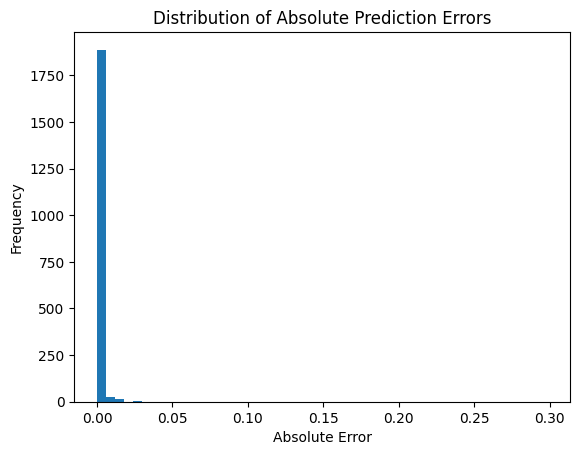

In [6]:
import matplotlib.pyplot as plt

# Create a histogram of the 'Absolute_Error' column
plt.hist(comparison_df['Absolute_Error'], bins=50)

# Add a title and labels to the histogram
plt.title('Distribution of Absolute Prediction Errors')
plt.xlabel('Absolute Error')
plt.ylabel('Frequency')

# Display the histogram
plt.show()

## Summary:

### Data Analysis Key Findings

*   The dataset contains 9669 entries and 16 columns with no missing values.
*   Numerical features (excluding `NORAD_CAT_ID` and `EPOCH_UNIX`) were scaled using `StandardScaler`.
*   A Random Forest Regressor model was trained to predict `APOGEE_ALTITUDE`.
*   The model achieved a Mean Squared Error (MSE) of approximately $5.44e-05$ on the test set.
*   The R-squared score on the test set is approximately 0.9999, indicating the model explains almost all the variance in the target variable.
*   The Mean Absolute Error (MAE) is approximately 0.00066.
*   The Root Mean Squared Error (RMSE) is approximately 0.00738.
*   A comparison of actual and predicted `APOGEE_ALTITUDE` values showed small absolute errors.
*   The mean absolute error was approximately 0.000656 with a standard deviation of approximately 0.007348.
*   The distribution of absolute prediction errors was visualized using a histogram.

### Insights or Next Steps

*   The trained Random Forest model shows very high accuracy in predicting the `APOGEE_ALTITUDE`, suggesting its potential for use in space debris tracking by predicting orbital parameters.
*   Further analysis could involve exploring feature importance from the Random Forest model to understand which features are most influential in predicting `APOGEE_ALTITUDE`.
